Importing the required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Reading the .csv file by creating a path variable containing the location of the .csv file and data being a variable storing all the data of the .csv file.

In [3]:

path = r"D:\Shourya\project_root\data\raw\DIB_Data\DIB_Data\DIB_Data\csvfiles\Capacity_Check\80per_Cells_Capacity_Check_08122021_080cycle\Cell15_80SOH_Capacity_Check_25degC_080cycle.csv"

data = pd.read_csv(path)


Succesfully printed the shape of the .csv file.

In [4]:
print(data.shape)

(21856, 14)


Succesfully printed the first 5 readings of the .csv file.

In [5]:
print(data.head(5))

  Step Status Step Time Prog Time Cycle Cycle Level               Procedure  \
0   []     []  [ss.xxx]  [ss.xxx]    []          []                      []   
1    1    ...         0         0     0           0  Recovas_Capacity_Check   
2    5    PAU     0.008      0.07     0           0  Recovas_Capacity_Check   
3    5    PAU     0.008      0.07     0           0  Recovas_Capacity_Check   
4    5    PAU   120.043   120.105     0           0  Recovas_Capacity_Check   

   Voltage Current AhAccu    AhPrev WhAccu    Watt LogTemp001  
0      [V]     [A]   [Ah]  [AhPrev]   [Wh]  [Watt]       [T1]  
1  3.30862       0    NaN       NaN    NaN     NaN        NaN  
2  3.30862       0    NaN       NaN    NaN     NaN        NaN  
3  3.30862       0      0         0      0       0       24.3  
4  3.30862       0      0         0      0       0       24.3  


Similarly printed the first 5 and last 5 data using .sample function

In [6]:
print(data.sample)

<bound method NDFrame.sample of        Step Status Step Time  Prog Time Cycle Cycle Level  \
0        []     []  [ss.xxx]   [ss.xxx]    []          []   
1         1    ...         0          0     0           0   
2         5    PAU     0.008       0.07     0           0   
3         5    PAU     0.008       0.07     0           0   
4         5    PAU   120.043    120.105     0           0   
...     ...    ...       ...        ...   ...         ...   
21851  9999    STO         0  26942.642     0           0   
21852  9999    STO         0  26942.642     0           0   
21853  9999    STO         0  26942.642     0           0   
21854  9999    STO         0  26942.642     0           0   
21855  9999    STO         0  26942.642     0           0   

                    Procedure  Voltage Current    AhAccu    AhPrev   WhAccu  \
0                          []      [V]     [A]      [Ah]  [AhPrev]     [Wh]   
1      Recovas_Capacity_Check  3.30862       0       NaN       NaN      NaN  

Step         - Step Number    	
Status	     - Whether we are charging or discharging or Pausing the process
Step Time	 - The time on clock for that specific Step
Prog Time    - Total time taken
Cycle        - No. of cycles completed
Cycle Level	 - Sub level inside a cycle
Procedure    - The process we are doing in this file for example it is Capacity Check
Voltage      - Instantaneous Cell Voltage
Current      - Instantaneous Current
AhAccu       - Accumulated Ampere-hours during this step.
AhPrev       - Accumulated Ah from previous steps
WhAccu       - Accumulated Watt-hours (energy):
Watt         - Instantaneous power:
LogTemp001   - The recorded temperature from the first temperature sensor.


Preparing For Diagnostics of the data

In [7]:
 print(data.describe())
print("\n")
data.info()
print("For Null Counts \n")
print("\n", data.isnull().sum() ,"\n")

         Step Status Step Time  Prog Time  Cycle Cycle Level  \
count   21856  21856     21856      21856  21856       21856   
unique      8      6     21579      21828      2           2   
top         6    CHA         0  26942.642      0           0   
freq    10428  10428        14          5  21855       21855   

                     Procedure  Voltage   Current    AhAccu AhPrev   WhAccu  \
count                    21856    21856     21856     21842  21842    21842   
unique                       2    12720      2405     19311      4    19905   
top     Recovas_Capacity_Check  4.19998  -1.66988  -0.14453      0  0.59172   
freq                     21855     1264      5331      1805  10443     1805   

         Watt LogTemp001  
count   21842      21842  
unique  17831         38  
top         0       25.4  
freq     1856       2904  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21856 entries, 0 to 21855
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dty

Basically there are 21856 columns.
The data is stored in object datatype specifying that it contains a mixture of both int, strings and everything.
Columns 0-8 have no null value, and columns from 9 to 13 have 14 missing values

In [8]:
# 1) drop columns with >50% missing
missing_pct = data.isna().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index
data = data.drop(columns=cols_to_drop)

# 2) impute small-missing columns using numeric mean (safe conversion)
cols_to_impute = missing_pct[(missing_pct > 0) & (missing_pct <= 0.5)].index
for col in cols_to_impute:
    num = pd.to_numeric(data[col], errors='coerce')   # convert safely
    mean = num.mean()                                 # mean of numeric values (NaNs ignored)
    if pd.isna(mean):
        # nothing numeric in this column — skip imputation
        continue
    data[col] = num.fillna(mean)

# 3) time-series fill for selected columns (convert to numeric first)
ts_cols = ['Voltage', 'Current', 'LogTemp001']   # change as needed
for col in ts_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce').ffill().bfill()

print("Missing handling complete.")


Missing handling complete.


In [9]:
print(data.isna().sum())

Step           0
Status         0
Step Time      0
Prog Time      0
Cycle          0
Cycle Level    0
Procedure      0
Voltage        0
Current        0
AhAccu         0
AhPrev         0
WhAccu         0
Watt           0
LogTemp001     0
dtype: int64


This shows that all the null values are now filled by their mean if the null percentage is less than 50% else they are omitted

In [10]:
import pandas as pd

# 1) Convert specific numeric columns
num_cols = ['Step Time','Prog Time','Voltage','Current','AhAccu','AhPrev','WhAccu','Watt','LogTemp001']

for col in num_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# 2) Convert integer-like columns
int_cols = ['Step','Cycle','Cycle Level']

for col in int_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64')

# 3) Convert categorical columns
cat_cols = ['Status','Procedure']

for col in cat_cols:
    if col in data.columns:
        data[col] = data[col].astype('category')

print(data.dtypes)


Step              Int64
Status         category
Step Time       float64
Prog Time       float64
Cycle             Int64
Cycle Level       Int64
Procedure      category
Voltage         float64
Current         float64
AhAccu          float64
AhPrev          float64
WhAccu          float64
Watt            float64
LogTemp001      float64
dtype: object


By this we have succesffully been able to convert the datatypes into the required datatype.

Time-series plots (Voltage, Current, Temperature)

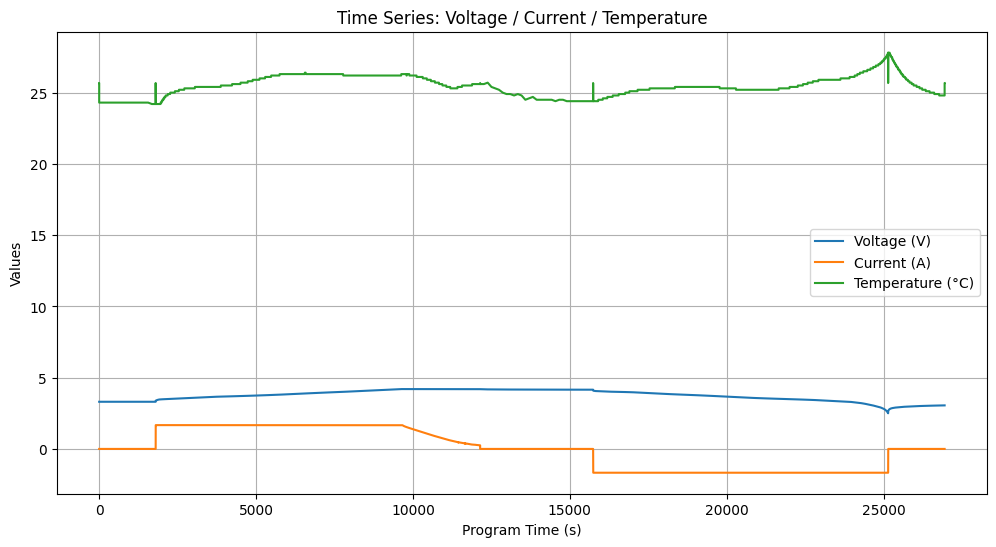

In [11]:

plt.figure(figsize=(12,6))
plt.plot(data['Prog Time'], data['Voltage'], label='Voltage (V)')
plt.plot(data['Prog Time'], data['Current'], label='Current (A)')
plt.plot(data['Prog Time'], data['LogTemp001'], label='Temperature (°C)')

plt.xlabel("Program Time (s)")
plt.ylabel("Values")
plt.title("Time Series: Voltage / Current / Temperature")
plt.legend()
plt.grid(True)
plt.show()


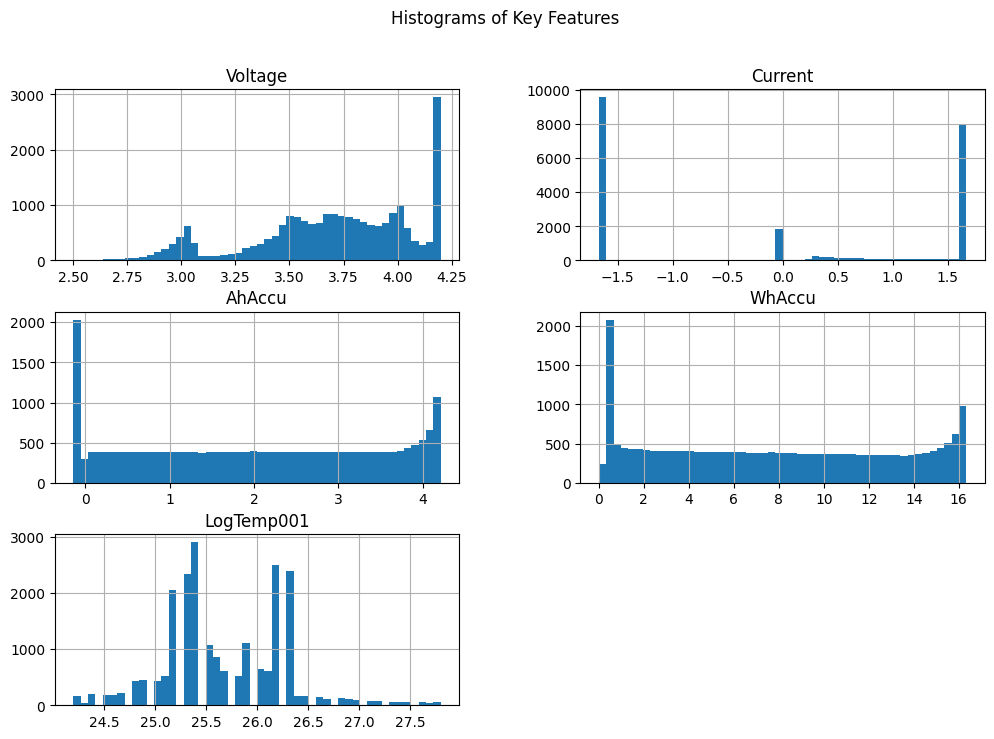

In [12]:
data[['Voltage','Current','AhAccu','WhAccu','LogTemp001']].hist(
    bins=50, figsize=(12,8), grid=True
)
plt.suptitle("Histograms of Key Features")
plt.show()



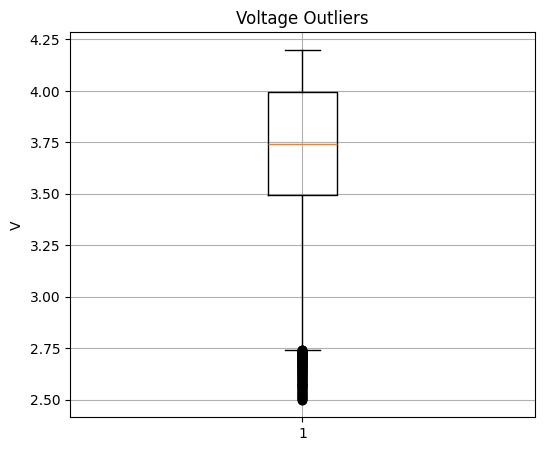

In [13]:
plt.figure(figsize=(6,5))
plt.boxplot(data['Voltage'].dropna())
plt.title("Voltage Outliers")
plt.ylabel("V")
plt.grid(True)
plt.show()


Inputs (X): Cycle, Voltage, Current, AhAccu, WhAccu, Watt, Temperature
Target (y): AhAccu (future or aggregated capacity)

In [14]:
X_cols = [
    'Cycle',
    'Voltage',
    'Current',
    'WhAccu',
    'Watt',
    'LogTemp001'
]

y_col = 'AhAccu'


print("Chosen features (X):", X_cols)
print("Chosen target (y):", y_col)

Chosen features (X): ['Cycle', 'Voltage', 'Current', 'WhAccu', 'Watt', 'LogTemp001']
Chosen target (y): AhAccu


In [15]:
import pandas as pd
import os

# ---- Start with your dataframe ----
df = data.copy()

# Ensure numeric columns
num_cols = ['Voltage','Current','AhAccu','WhAccu','LogTemp001']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cycle number
df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')

# 1. Cumulative charge/energy
df['Cum_Ah'] = df['AhAccu'].cumsum()
df['Cum_Wh'] = df['WhAccu'].cumsum()

# 2. Rolling stats (window=5 & 10)
for w in [5, 10]:
    df[f'Volt_roll_mean_{w}'] = df['Voltage'].rolling(w).mean()
    df[f'Volt_roll_std_{w}']  = df['Voltage'].rolling(w).std()

    df[f'Curr_roll_mean_{w}'] = df['Current'].rolling(w).mean()
    df[f'Curr_roll_std_{w}']  = df['Current'].rolling(w).std()

    df[f'Temp_roll_mean_{w}'] = df['LogTemp001'].rolling(w).mean()
    df[f'Temp_roll_std_{w}']  = df['LogTemp001'].rolling(w).std()

# 3. Delta features
df['Delta_Voltage'] = df['Voltage'].diff()
df['Delta_Current'] = df['Current'].diff()
df['Delta_Temp']    = df['LogTemp001'].diff()
df['Delta_Ah']      = df['AhAccu'].diff()

# 4. Temperature range (window 10)
df['Temp_range_10'] = df['LogTemp001'].rolling(10).max() - df['LogTemp001'].rolling(10).min()


# 5. Normalizing data
from sklearn.preprocessing import StandardScaler

# Select only numeric features (X)
X = df[X_cols].copy()
y = df[y_col].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X_cols,
    index=df.index
)

print("Normalization complete.")


# ---- SAVE HERE ----
save_path = r"D:\Shourya\project_root\data\processed\processed_battery_data.csv"

df.to_csv(save_path, index=False)

print("Feature engineering complete!")
print("Saved to:", save_path)


Normalization complete.
Feature engineering complete!
Saved to: D:\Shourya\project_root\data\processed\processed_battery_data.csv


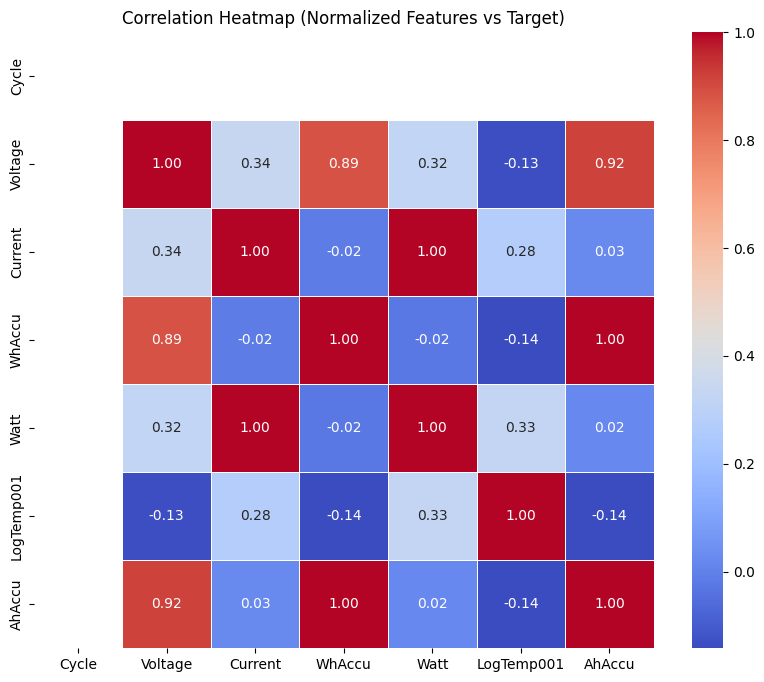

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only features + target
# Correlation between normalized inputs and target
corr_df = pd.concat([X_scaled, y], axis=1).corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap (Normalized Features vs Target)")
plt.show()


Since 1 stands for High Correlation therefore we conclude:
    1. AhAccu is positively related with voltage (True)
    2. Since cycle has no colour it means cycle has no relation with anything
    3. AhAccu is very little affected by Current
    4. AhAccu is inversely proportional to Temperature (because more the temperature flow of charge would be faster so accumulation would be lesser)

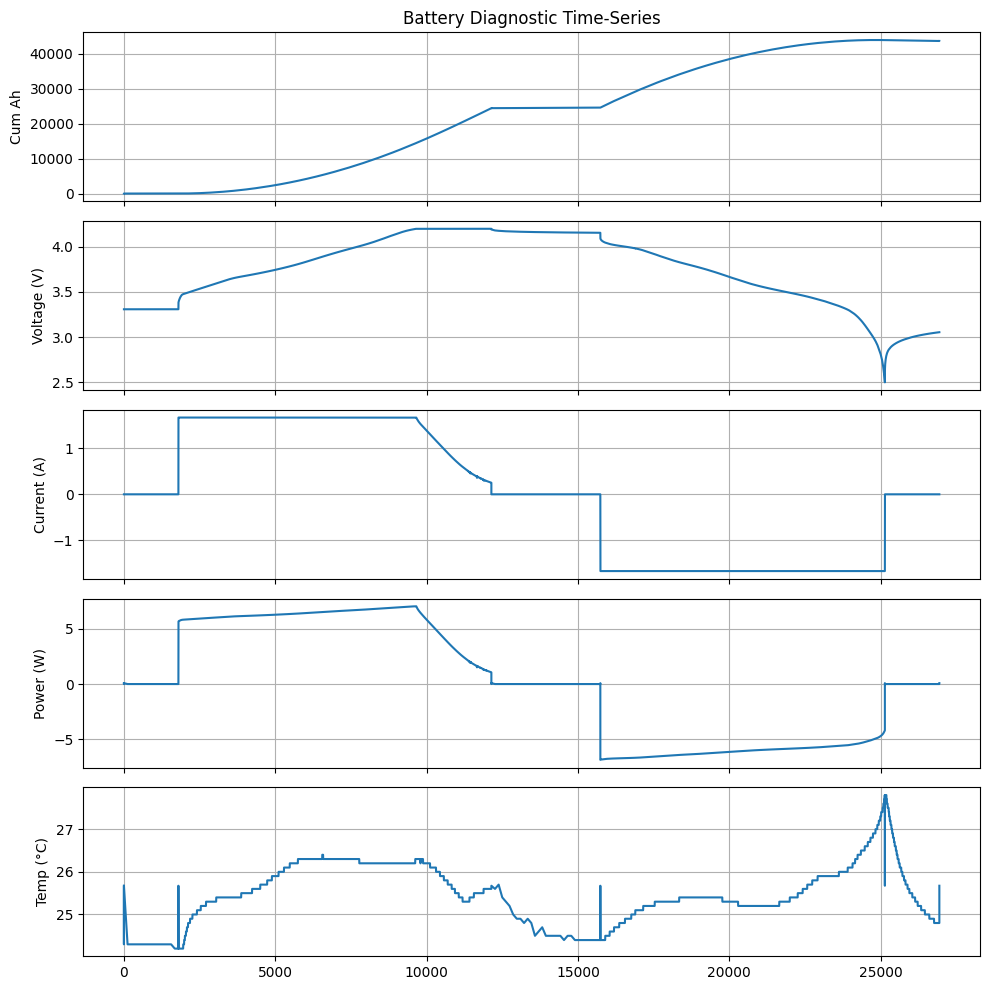

In [23]:
import matplotlib.pyplot as plt

# Sort by program time
df_sorted = df.sort_values('Prog Time')
t = df_sorted['Prog Time']

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 10),
    sharex=True
)

# 1. Cumulative Charge
axes[0].plot(t, df_sorted['Cum_Ah'])
axes[0].set_ylabel("Cum Ah")
axes[0].set_title("Battery Diagnostic Time-Series")
axes[0].grid(True)

# 2. Voltage
axes[1].plot(t, df_sorted['Voltage'])
axes[1].set_ylabel("Voltage (V)")
axes[1].grid(True)

# 3. Current
axes[2].plot(t, df_sorted['Current'])
axes[2].set_ylabel("Current (A)")
axes[2].grid(True)

# 4. Power
axes[3].plot(t, df_sorted['Watt'])
axes[3].set_ylabel("Power (W)")
axes[3].grid(True)

# 5. Temperature
axes[4].plot(t, df_sorted['LogTemp001'])
axes[4].set_ylabel("Temp (°C)")
axes[4].grid(True)


plt.tight_layout()
plt.show()
